In [1]:
import pandas as pd
from matplotlib import pyplot as plt
from collections import Counter
import numpy as np
FILE_PATH = "../data/enron_spam_data.csv"

In [10]:
df = pd.read_csv(FILE_PATH)
df.set_index("Message ID", inplace=True)
df["Subject"] = df["Subject"].fillna("")
df["Message"] = df["Message"].fillna("")
df["Message_full"] = df["Subject"] + " - " + df["Message"]

In [11]:
df.columns

Index(['Subject', 'Message', 'Spam/Ham', 'Date', 'Message_full'], dtype='object')

In [12]:
df.head()

,Subject,Message,Spam/Ham,Date,Message_full
Message ID,,,,,
0,christmas tree farm pictures,,ham,1999-12-10,christmas tree farm pictures -
1,"vastar resources , inc .","gary , production from the high island larger ...",ham,1999-12-13,"vastar resources , inc . - gary , production f..."
2,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,1999-12-14,calpine daily gas nomination - - calpine daily...
3,re : issue,fyi - see note below - already done .\nstella\...,ham,1999-12-14,re : issue - fyi - see note below - already do...
4,meter 7268 nov allocation,fyi .\n- - - - - - - - - - - - - - - - - - - -...,ham,1999-12-14,meter 7268 nov allocation - fyi .\n- - - - - -...


In [13]:
df[df["Spam/Ham"] == "spam"]["Message_full"].head()

Message ID
3672    dobmeos with hgh my energy level has gone up !...
3673    your prescription is ready . . oxwq s f e - lo...
3674    get that new car 8434 - people nowthe weather ...
3675    await your response - dear partner ,\nwe are a...
3676    coca cola , mbna america , nascar partner with...
Name: Message_full, dtype: object

In [15]:
df["Message_full"][3672]

'dobmeos with hgh my energy level has gone up ! stukm - introducing\ndoctor - formulated\nhgh\nhuman growth hormone - also called hgh\nis referred to in medical science as the master hormone . it is very plentiful\nwhen we are young , but near the age of twenty - one our bodies begin to produce\nless of it . by the time we are forty nearly everyone is deficient in hgh ,\nand at eighty our production has normally diminished at least 90 - 95 % .\nadvantages of hgh :\n- increased muscle strength\n- loss in body fat\n- increased bone density\n- lower blood pressure\n- quickens wound healing\n- reduces cellulite\n- improved vision\n- wrinkle disappearance\n- increased skin thickness texture\n- increased energy levels\n- improved sleep and emotional stability\n- improved memory and mental alertness\n- increased sexual potency\n- resistance to common illness\n- strengthened heart muscle\n- controlled cholesterol\n- controlled mood swings\n- new hair growth and color restore\nread\nmore at thi

In [19]:
df[df["Spam/Ham"] == "ham"]["Message_full"].head()

Message ID
0                      christmas tree farm pictures - 
1    vastar resources , inc . - gary , production f...
2    calpine daily gas nomination - - calpine daily...
3    re : issue - fyi - see note below - already do...
4    meter 7268 nov allocation - fyi .\n- - - - - -...
Name: Message_full, dtype: object

In [20]:
df["Message_full"][0]

'christmas tree farm pictures - '

In [21]:
df.shape

(33716, 5)

In [23]:
df[df.duplicated(["Message_full"])]

,Subject,Message,Spam/Ham,Date,Message_full
Message ID,,,,,
505,calpine daily gas nomination,- calpine daily gas nomination 1 . doc,ham,2000-03-22,calpine daily gas nomination - - calpine daily...
1209,cornhusker - gas management,i thought it might be helpful to summarize the...,ham,2000-07-17,cornhusker - gas management - i thought it mig...
1228,re : cornhusker,"john ,\ni did some preliminary work on your qu...",ham,2000-07-20,"re : cornhusker - john ,\ni did some prelimina..."
1276,cleburne,"daren & john ,\nsee the attached document rega...",ham,2000-07-27,"cleburne - daren & john ,\nsee the attached do..."
1292,calpine daily gas nomination,>\nricky a . archer\nfuel supply\n700 louisian...,ham,2000-07-31,calpine daily gas nomination - >\nricky a . ar...
...,...,...,...,...,...
33698,re [ 6 ] : letter about his warez,mult\ngua\nmsof\nre !\nilan\ngeoe\ntwa\nnonee\...,spam,2005-07-29,re [ 6 ] : letter about his warez - mult\ngua\...
33701,re [ 5 ] : question about our progs,mult\ngua\nmsof\nre !\nilan\ngeoe\ntwa\nnonee\...,spam,2005-07-29,re [ 5 ] : question about our progs - mult\ngu...
33705,reduzca sus gastos telefonicos,empresa lider mundial le permite utilizar su n...,spam,2005-07-29,reduzca sus gastos telefonicos - empresa lider...


In [25]:
# Class repartition

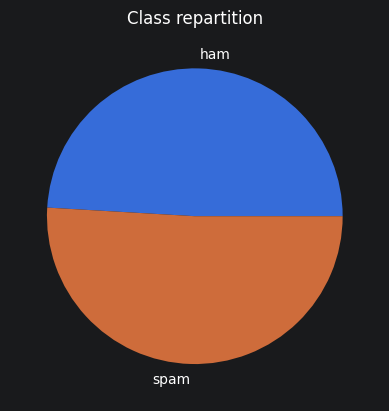

In [26]:
class_repartition = Counter(df["Spam/Ham"])

labels = list(class_repartition.keys())
values = list(class_repartition.values())

plt.figure()
plt.pie(values, labels=labels)
plt.title("Class repartition")
plt.show()


In [27]:
# Text length

In [30]:
df['num_words'] = df["Message_full"].apply(lambda x: len(x.split()))
df['num_characters'] = df["Message_full"].apply(lambda x: len(x))

In [31]:
print(f"Words number mean : {df['num_words'].mean()}")
print(f"Words number max : {df['num_words'].max()}")
print(f"Words number min : {df['num_words'].min()}")

Words number mean : 311.5928046031558
Words number max : 45451
Words number min : 1


In [32]:
print(f"Character number mean : {df['num_characters'].mean()}")
print(f"Character number max : {df['num_characters'].max()}")
print(f"Character number min : {df['num_characters'].min()}")

Character number mean : 1507.8974374184363
Character number max : 228370
Character number min : 3


In [33]:
## SPAM VS HAM - num_words

In [64]:
max_word_threshold = 1000
step = 100
df["num_words_rounded"] = np.ceil(df["num_words"] / step) * step
df["num_words_rounded"] = df["num_words_rounded"].apply(lambda x: max_word_threshold if x < max_word_threshold and x > (max_word_threshold-step) else x)
words_abscissa = [x+step for x in range(0, max_word_threshold, step)]

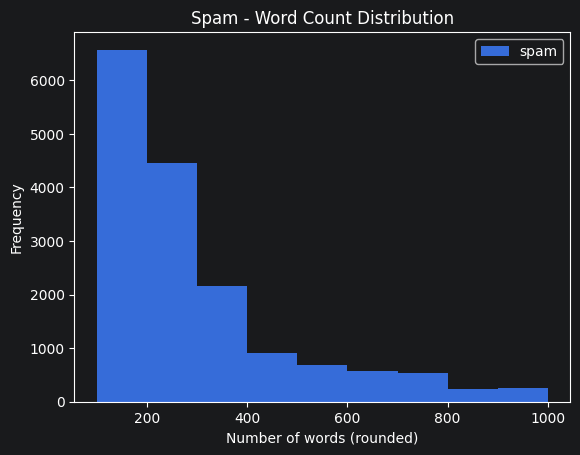

In [65]:
plt.figure()
plt.hist(
    df[df["Spam/Ham"] == "spam"]["num_words_rounded"],
    bins=words_abscissa,
    label="spam")
plt.xlabel("Number of words (rounded)")
plt.ylabel("Frequency")
plt.title("Spam - Word Count Distribution")
plt.legend()
plt.show()

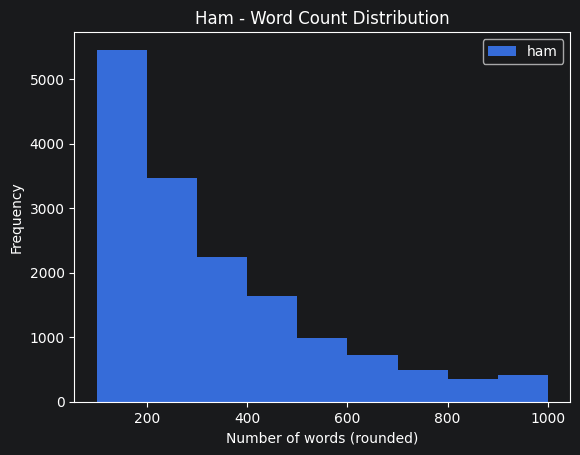

In [66]:
plt.figure()
plt.hist(
    df[df["Spam/Ham"] == "ham"]["num_words_rounded"],
    bins=words_abscissa,
    label="ham"
)
plt.xlabel("Number of words (rounded)")
plt.ylabel("Frequency")
plt.title("Ham - Word Count Distribution")
plt.legend()
plt.show()

In [67]:
df.groupby("Spam/Ham")["num_words"].mean()

Spam/Ham
ham     362.800302
spam    262.252169
Name: num_words, dtype: float64

In [68]:
## SPAM VS HAM - num_characters

In [73]:
max_char_threshold = 10000
df["num_characters_rounded"] = np.ceil(df["num_characters"] / step) * step
df["num_characters_rounded"] = df["num_characters_rounded"].apply(lambda x: max_char_threshold if x < max_char_threshold and x > (max_char_threshold-step) else x)
char_abscissa = [x+step for x in range(0, max_char_threshold, step)]

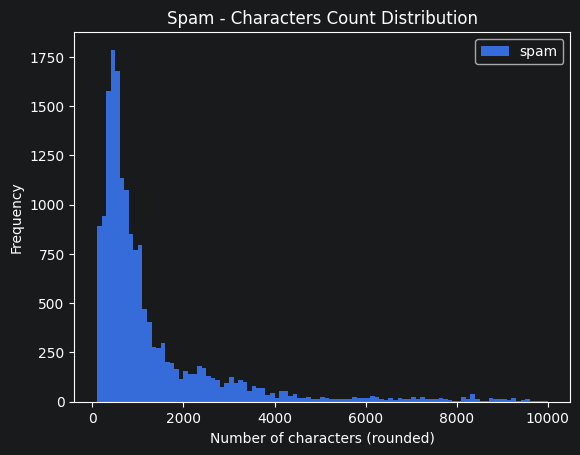

In [74]:
plt.figure()
plt.hist(
    df[df["Spam/Ham"] == "spam"]["num_characters_rounded"],
    bins=char_abscissa,
    label="spam")
plt.xlabel("Number of characters (rounded)")
plt.ylabel("Frequency")
plt.title("Spam - Characters Count Distribution")
plt.legend()
plt.show()

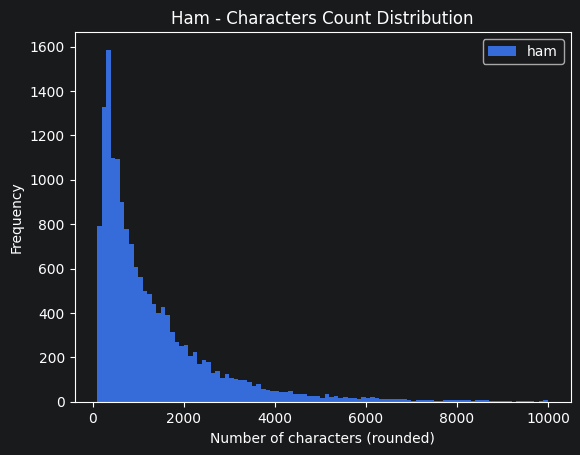

In [75]:
plt.figure()
plt.hist(
    df[df["Spam/Ham"] == "ham"]["num_characters_rounded"],
    bins=char_abscissa,
    label="ham"
)
plt.xlabel("Number of characters (rounded)")
plt.ylabel("Frequency")
plt.title("Ham - Characters Count Distribution")
plt.legend()
plt.show()

In [77]:
df.groupby("Spam/Ham")["num_characters"].mean()

Spam/Ham
ham     1710.443034
spam    1312.736008
Name: num_characters, dtype: float64